<a href="https://colab.research.google.com/github/Mounikapaili/Mounika/blob/main/covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Covid_19_Clean_Complete (1).csv')
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
16510,Liaoning,China,41.29560,122.608500,2020-03-25,127,2,124,1,Western Pacific
16511,Macau,China,22.16670,113.550000,2020-03-25,30,0,10,20,Western Pacific
16512,Ningxia,China,37.26920,106.165500,2020-03-25,75,0,75,0,Western Pacific
16513,Qinghai,China,35.74520,95.995600,2020-03-25,18,0,18,0,Western Pacific


In [ ]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
16510,Liaoning,China,41.29560,122.608500,2020-03-25,127,2,124,1,Western Pacific
16511,Macau,China,22.16670,113.550000,2020-03-25,30,0,10,20,Western Pacific
16512,Ningxia,China,37.26920,106.165500,2020-03-25,75,0,75,0,Western Pacific
16513,Qinghai,China,35.74520,95.995600,2020-03-25,18,0,18,0,Western Pacific


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16515 entries, 0 to 16514
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  4956 non-null   object 
 1   Country/Region  16515 non-null  object 
 2   Lat             16515 non-null  float64
 3   Long            16515 non-null  float64
 4   Date            16515 non-null  object 
 5   Confirmed       16515 non-null  int64  
 6   Deaths          16515 non-null  int64  
 7   Recovered       16515 non-null  int64  
 8   Active          16515 non-null  int64  
 9   WHO Region      16515 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 1.3+ MB


In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
df.rename(columns={'Province/State':'State','Country/Region':'country'},inplace=True)

In [ ]:
df.Date.value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-02-25,261
2020-02-26,261
2020-02-27,261
...,...
2020-02-17,261
2020-02-18,261
2020-02-19,261


In [ ]:
df['Date'].max()

Timestamp('2020-03-25 00:00:00')

In [ ]:
top=df[df['Date']=='2020-07-27']
top

,State,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region


In [ ]:
top.groupby(by='country')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

,country,Confirmed,Deaths,Recovered,Active


In [ ]:
confirmed=df.groupby(by='Date')["Confirmed"].sum().reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
59,2020-03-21,308175
60,2020-03-22,341585
61,2020-03-23,383750
62,2020-03-24,424889


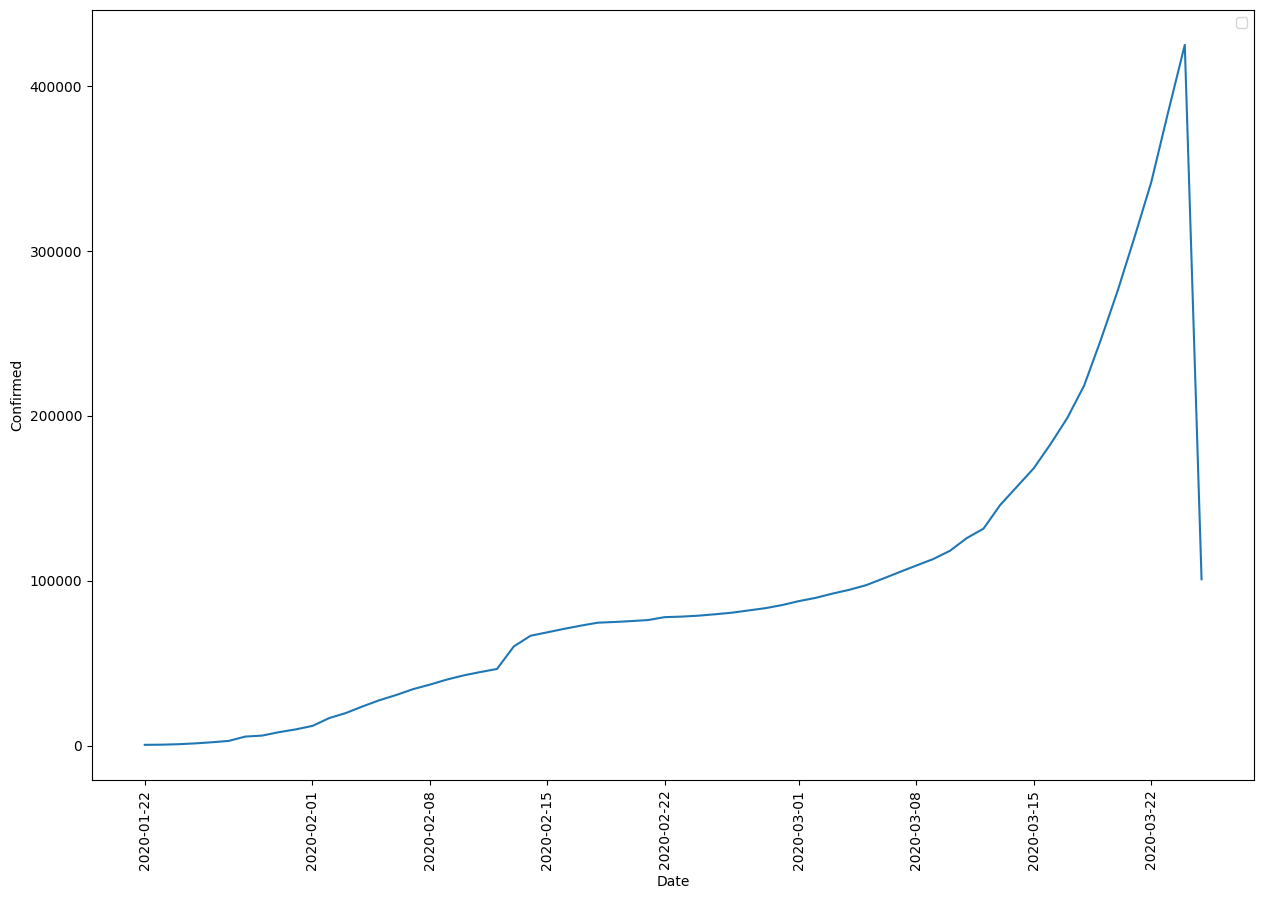

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(x='Date',y='Confirmed',data=confirmed)
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [ ]:
top_10=df.groupby(by="country")['Recovered'].sum().sort_values(ascending=False).head(10).reset_index()

In [ ]:
top_10

,country,Recovered
0,China,1875116
1,Iran,88842
2,Italy,59280
3,South Korea,21388
4,Spain,18162
5,France,8016
6,Germany,5071
7,Japan,3266
8,Singapore,3138
9,Belgium,1890


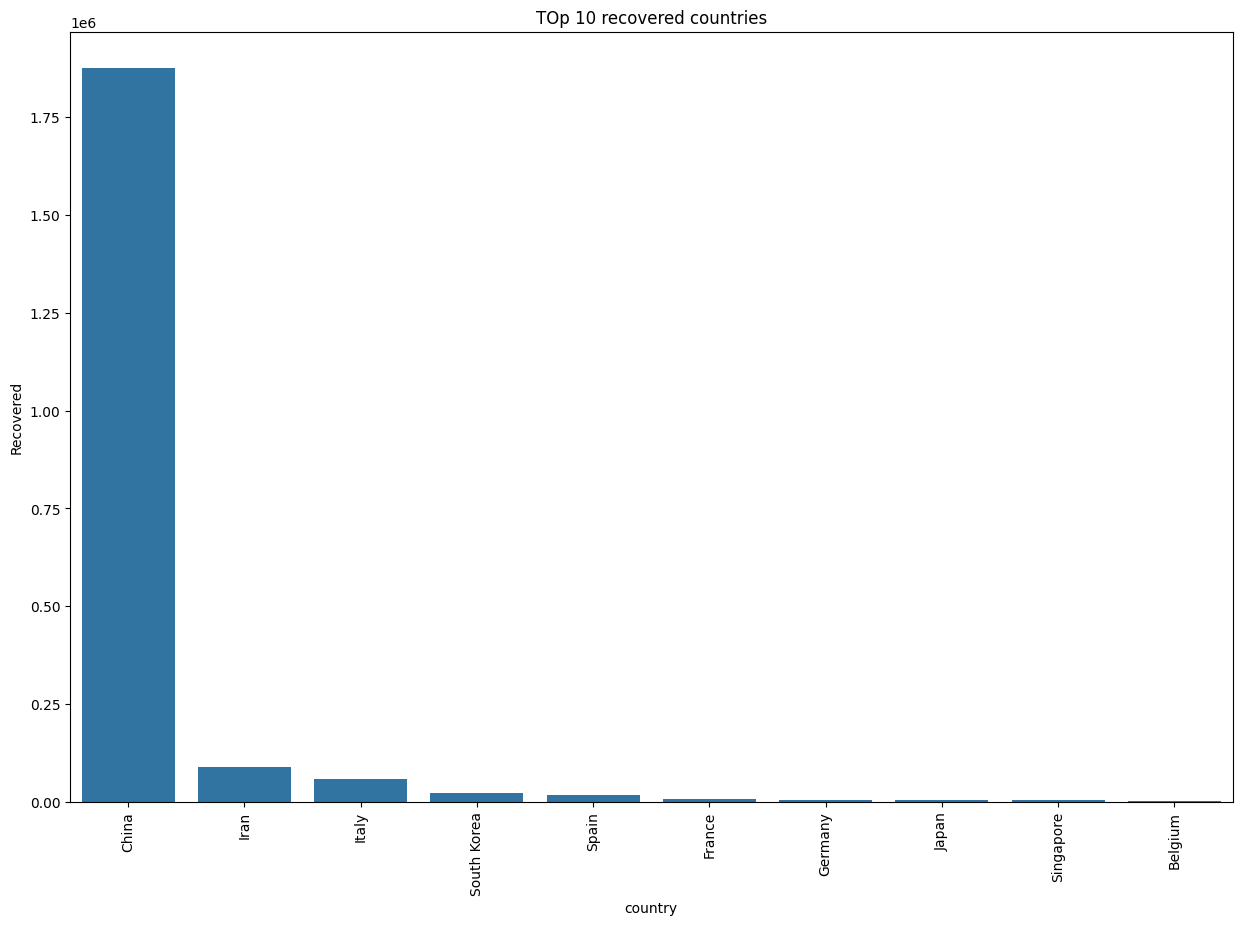

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(x='country',y='Recovered',data=top_10)
plt.title("TOp 10 recovered countries")
plt.xticks(rotation=90)
plt.show()

In [ ]:
top_10_deaths=df.groupby(by='country')["Deaths"].sum().sort_values(ascending=False).head(10).reset_index()

In [ ]:
top_10_deaths

,country,Deaths
0,China,125963
1,Italy,47045
2,Iran,16870
3,Spain,12464
4,France,4831
5,US,4301
6,United Kingdom,2136
7,South Korea,1677
8,Netherlands,1181
9,Germany,675


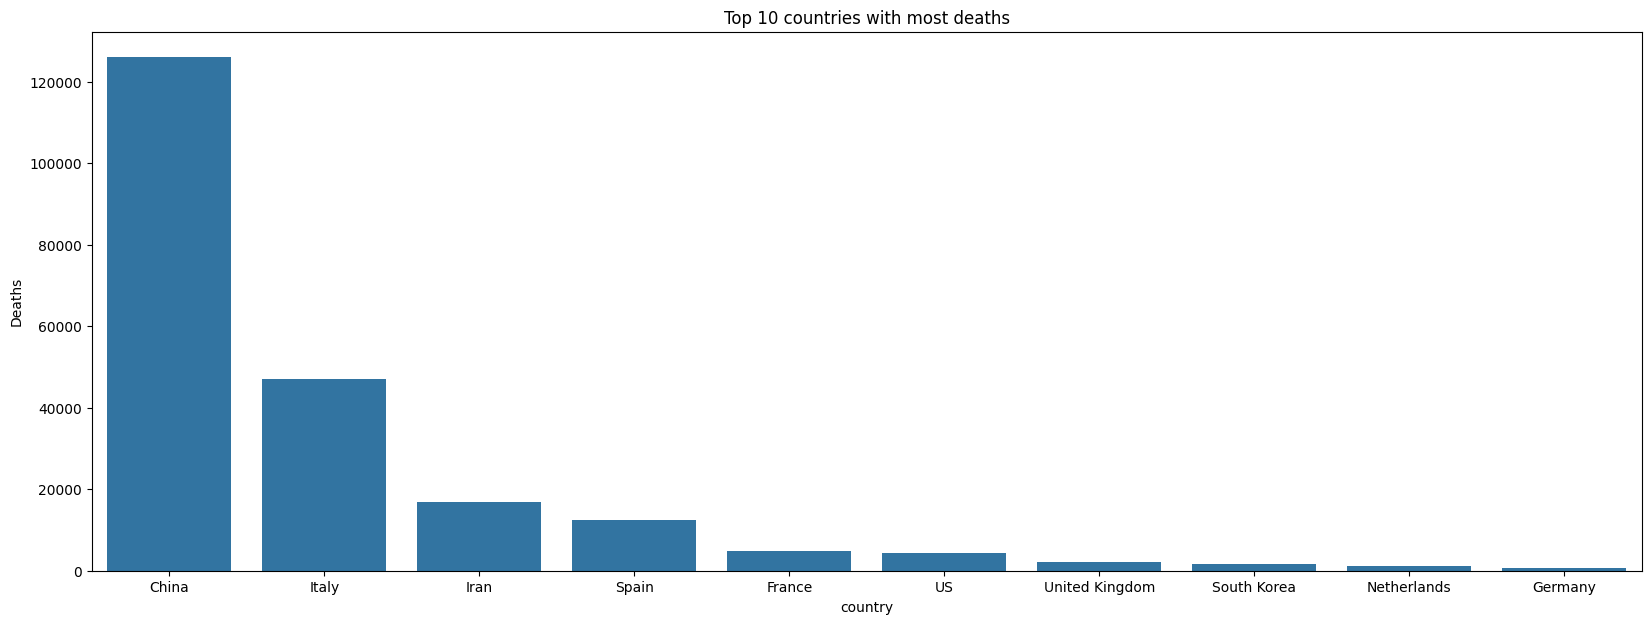

In [ ]:
plt.figure(figsize = (20,7))
sns.barplot(data = top_10_deaths, x = 'country', y = 'Deaths')
plt.title('Top 10 countries with most deaths')
plt.show()

In [ ]:
top_10_active=df.groupby(by='country')['Active'].sum().sort_values(ascending=False).head(10).reset_index()
top_10_active

,country,Active
0,China,1691425
1,Italy,468250
2,US,218554
3,Spain,201827
4,Germany,192397
5,Iran,173280
6,South Korea,167799
7,France,132602
8,United Kingdom,87575
9,Switzerland,56930


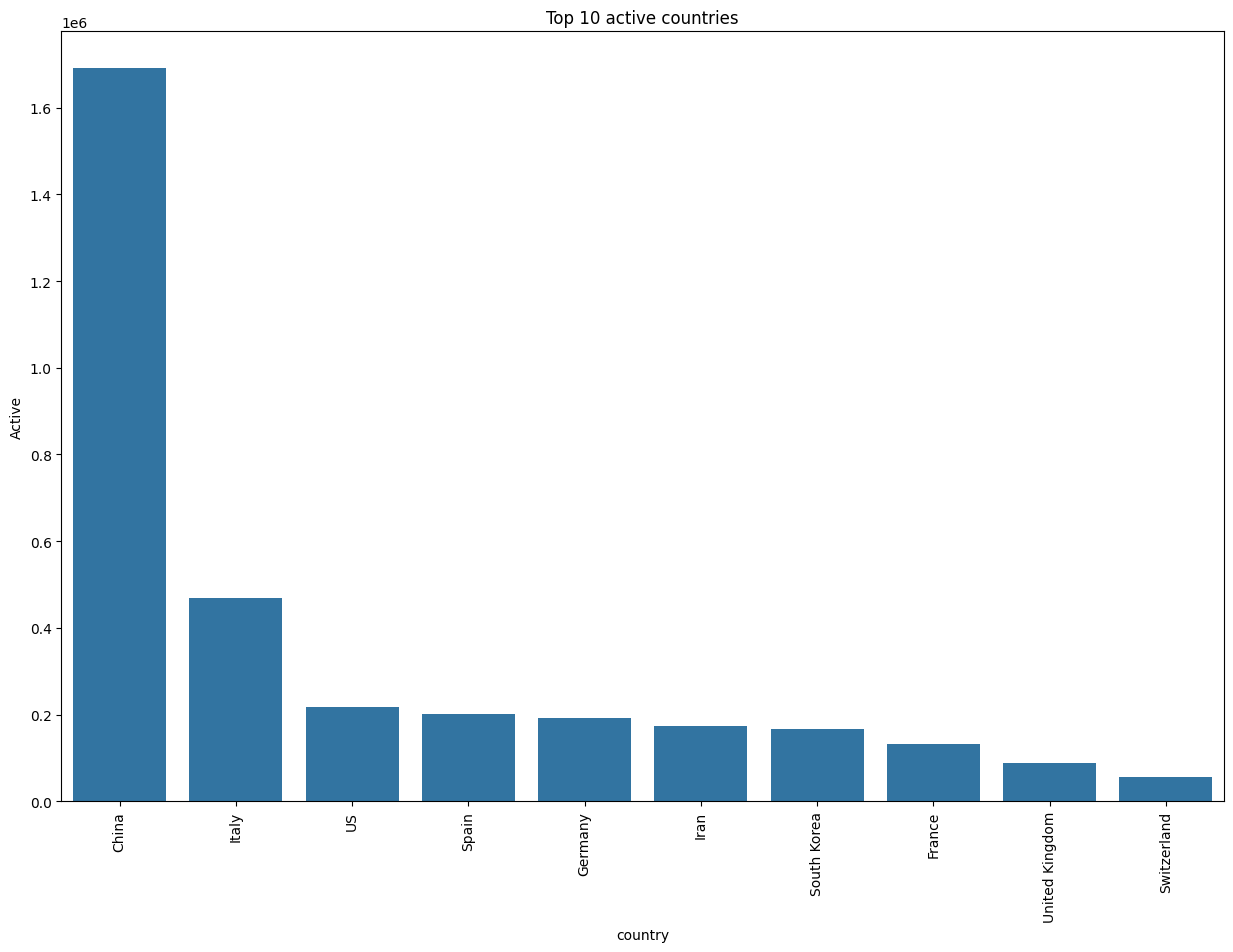

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(x='country',y='Active',data=top_10_active)
plt.title("Top 10 active countries")
plt.xticks(rotation=90)
plt.show()

In [ ]:
US = df[df['country'] == 'US']
US.head()

,State,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas


In [ ]:
US=US.groupby(by='Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

In [ ]:
US

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
58,2020-03-20,19479,362,147,18970
59,2020-03-21,25825,456,176,25193
60,2020-03-22,33761,601,178,32982
61,2020-03-23,43850,784,178,42888


In [ ]:
China=df[df['country']=='China']
china=China.groupby(by='Date')[['Confirmed','Recovered','Active','Deaths']].sum().reset_index()

In [ ]:
china

,Date,Confirmed,Recovered,Active,Deaths
0,2020-01-22,548,28,503,17
1,2020-01-23,643,30,595,18
2,2020-01-24,920,36,858,26
3,2020-01-25,1406,39,1325,42
4,2020-01-26,2075,49,1970,56
...,...,...,...,...,...
59,2020-03-21,81305,70297,7749,3259
60,2020-03-22,81435,70802,7359,3274
61,2020-03-23,81498,71254,6970,3274
62,2020-03-24,81591,71720,6590,3281


In [ ]:
India=df[df['country']=='India']
india=India.groupby(by='Date')[['Confirmed','Recovered','Active','Deaths']].sum().reset_index()
india

,Date,Confirmed,Recovered,Active,Deaths
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
58,2020-03-20,244,20,219,5
59,2020-03-21,330,23,303,4
60,2020-03-22,396,27,362,7
61,2020-03-23,499,27,462,10


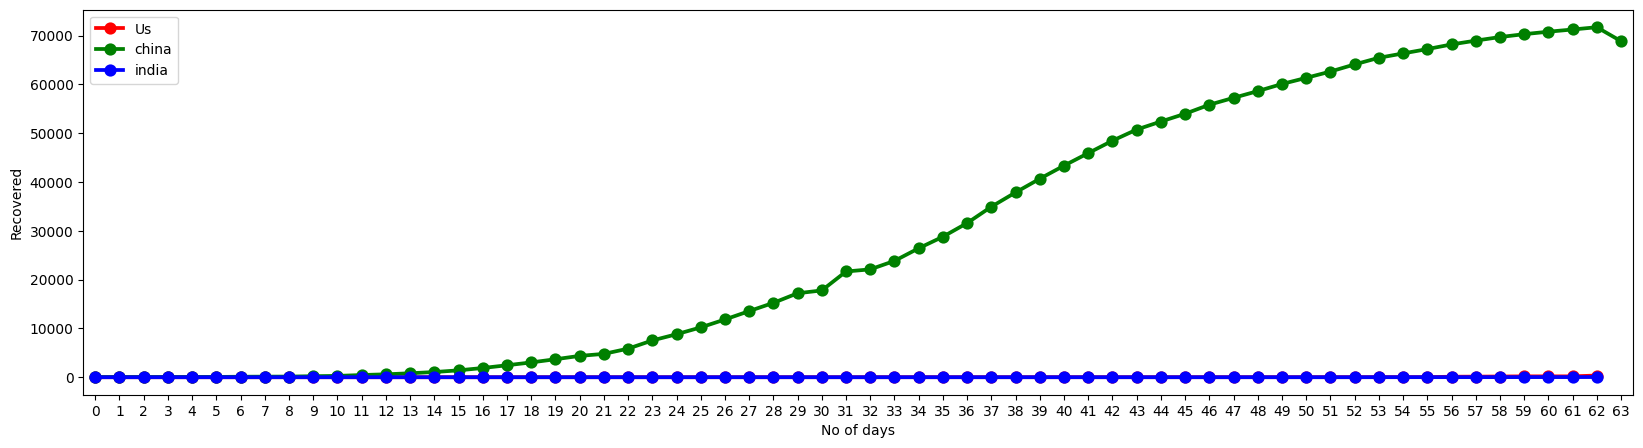

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(x=US.index,y=US.Recovered,color='Red',label='Us')
sns.pointplot(x=china.index,y=china.Recovered,color='Green',label='china')
sns.pointplot(x=india.index,y=india.Recovered,color='Blue',label='india')
plt.xlabel('No of days',fontsize=10)
plt.ylabel('Recovered',fontsize=10)
plt.legend()
plt.show()


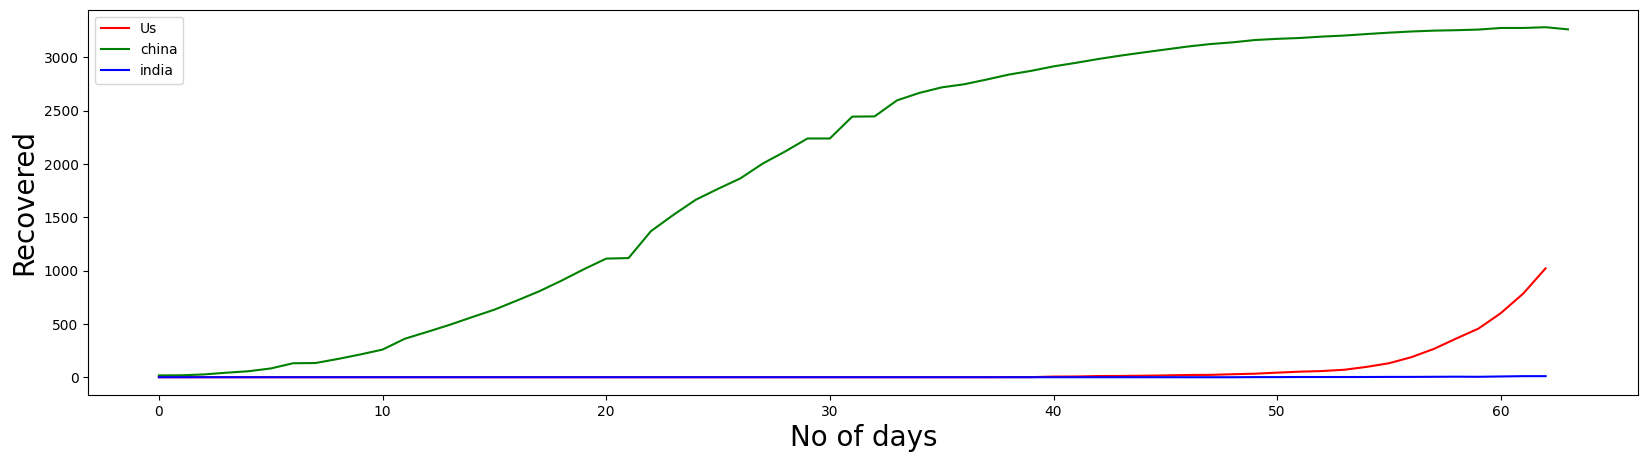

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(x=US.index,y=US.Deaths,color='Red',label='Us')
sns.lineplot(x=china.index,y=china.Deaths,color='Green',label='china')
sns.lineplot(x=india.index,y=india.Deaths,color='Blue',label='india')
plt.xlabel('No of days',fontsize=20)
plt.ylabel('Recovered',fontsize=20)
plt.legend()
plt.show()

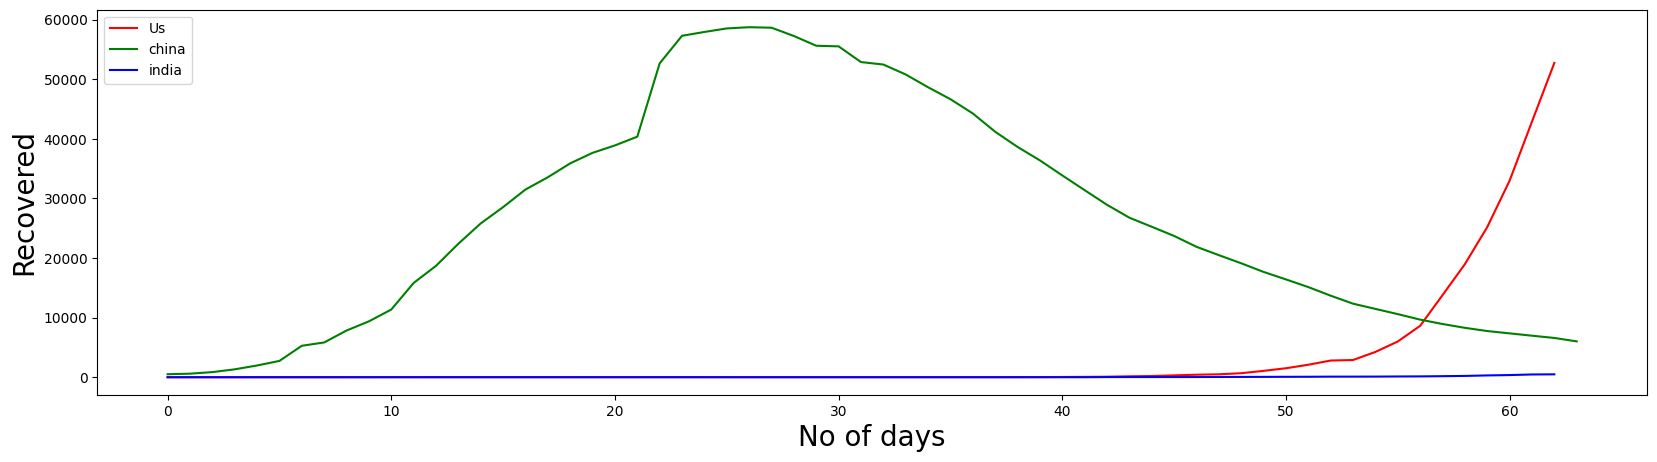

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(x=US.index,y=US.Active,color='Red',label='Us')
sns.lineplot(x=china.index,y=china.Active,color='Green',label='china')
sns.lineplot(x=india.index,y=india.Active,color='Blue',label='india')
plt.xlabel('No of days',fontsize=20)
plt.ylabel('Recovered',fontsize=20)
plt.legend()
plt.show()

In [ ]:
!pip install prophet

In [ ]:
df1 = pd.read_csv('/content/Covid_19_Clean_Complete (1).csv', parse_dates=['Date'])
df1.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0.0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0.0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0.0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0.0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0.0,Africa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16515 entries, 0 to 16514
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   State       4956 non-null   object        
 1   country     16515 non-null  object        
 2   Lat         16515 non-null  float64       
 3   Long        16515 non-null  float64       
 4   Date        16515 non-null  datetime64[ns]
 5   Confirmed   16515 non-null  int64         
 6   Deaths      16515 non-null  int64         
 7   Recovered   16515 non-null  int64         
 8   Active      16515 non-null  int64         
 9   WHO Region  16515 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 1.3+ MB


In [ ]:
confirmed=df1.groupby(by='Date')["Confirmed"].sum().reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
118,2020-05-19,4900702
119,2020-05-20,5003730
120,2020-05-21,5110064
121,2020-05-22,5216964


In [ ]:
deaths=df1.groupby(by='Date')["Deaths"].sum().reset_index()
deaths

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
118,2020-05-19,324441
119,2020-05-20,329326
120,2020-05-21,334112
121,2020-05-22,339396


In [ ]:
active=df1.groupby(by='Date')["Active"].sum().reset_index()
active

,Date,Active
0,2020-01-22,510.0
1,2020-01-23,606.0
2,2020-01-24,879.0
3,2020-01-25,1353.0
4,2020-01-26,2010.0
...,...,...
118,2020-05-19,2784005.0
119,2020-05-20,2823963.0
120,2020-05-21,2875184.0
121,2020-05-22,2869027.0


In [ ]:
recovered=df1.groupby(by='Date')["Recovered"].sum().reset_index()
recovered

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
118,2020-05-19,1792256
119,2020-05-20,1850441
120,2020-05-21,1900768
121,2020-05-22,2008541


In [ ]:
df1 = pd.read_csv('/content/Covid_19_Clean_Complete (1).csv', parse_dates=['Date'])
df1.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0.0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0.0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0.0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0.0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0.0,Africa


In [ ]:
confirmed = df1.groupby(by='Date')['Confirmed'].sum().reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
118,2020-05-19,4900702
119,2020-05-20,5003730
120,2020-05-21,5110064
121,2020-05-22,5216964


In [ ]:
recovered = df1.groupby(by='Date')['Recovered'].sum().reset_index()
recovered

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
118,2020-05-19,1792256
119,2020-05-20,1850441
120,2020-05-21,1900768
121,2020-05-22,2008541


In [ ]:
deaths = df1.groupby(by='Date')['Deaths'].sum().reset_index()
deaths

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
118,2020-05-19,324441
119,2020-05-20,329326
120,2020-05-21,334112
121,2020-05-22,339396


In [ ]:
active = df1.groupby(by='Date')['Active'].sum().reset_index()
active

,Date,Active
0,2020-01-22,510.0
1,2020-01-23,606.0
2,2020-01-24,879.0
3,2020-01-25,1353.0
4,2020-01-26,2010.0
...,...,...
118,2020-05-19,2784005.0
119,2020-05-20,2823963.0
120,2020-05-21,2875184.0
121,2020-05-22,2869027.0


In [ ]:
from prophet import Prophet

In [ ]:
m=Prophet()

In [ ]:
confirmed.columns = ['ds','y']
confirmed.head()

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [ ]:
m.fit(confirmed)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqi8178pr/cfrc32d7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqi8178pr/5u2e24gg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=97587', 'data', 'file=/tmp/tmpqi8178pr/cfrc32d7.json', 'init=/tmp/tmpqi8178pr/5u2e24gg.json', 'output', 'file=/tmp/tmpqi8178pr/prophet_model1tet41_b/prophet_model-20250205020035.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:00:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:00:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = m.make_future_dataframe(periods=7)

forecast = m.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.689937e+04,-5.282782e+05,4.285822e+05,-9.689937e+04,-9.689937e+04,33753.569742,33753.569742,33753.569742,33753.569742,33753.569742,33753.569742,0.0,0.0,0.0,-6.314580e+04
1,2020-01-23,-9.180368e+04,-5.336707e+05,4.412488e+05,-9.180368e+04,-9.180368e+04,41509.452271,41509.452271,41509.452271,41509.452271,41509.452271,41509.452271,0.0,0.0,0.0,-5.029422e+04
2,2020-01-24,-8.670799e+04,-5.266654e+05,4.409819e+05,-8.670799e+04,-8.670799e+04,48789.301424,48789.301424,48789.301424,48789.301424,48789.301424,48789.301424,0.0,0.0,0.0,-3.791868e+04
3,2020-01-25,-8.161229e+04,-8.162234e+05,2.172041e+05,-8.161229e+04,-8.161229e+04,-202321.958126,-202321.958126,-202321.958126,-202321.958126,-202321.958126,-202321.958126,0.0,0.0,0.0,-2.839343e+05
4,2020-01-26,-7.651660e+04,-5.223336e+05,4.628187e+05,-7.651660e+04,-7.651660e+04,26236.140388,26236.140388,26236.140388,26236.140388,26236.140388,26236.140388,0.0,0.0,0.0,-5.028046e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,2020-05-26,5.017582e+06,4.555621e+06,5.539015e+06,5.013513e+06,5.021021e+06,26562.174838,26562.174838,26562.174838,26562.174838,26562.174838,26562.174838,0.0,0.0,0.0,5.044144e+06
126,2020-05-27,5.089204e+06,4.638775e+06,5.645315e+06,5.081887e+06,5.095807e+06,33753.569742,33753.569742,33753.569742,33753.569742,33753.569742,33753.569742,0.0,0.0,0.0,5.122957e+06
127,2020-05-28,5.160826e+06,4.698848e+06,5.672483e+06,5.149677e+06,5.171229e+06,41509.452271,41509.452271,41509.452271,41509.452271,41509.452271,41509.452271,0.0,0.0,0.0,5.202335e+06
128,2020-05-29,5.232448e+06,4.723010e+06,5.761311e+06,5.217797e+06,5.246919e+06,48789.301424,48789.301424,48789.301424,48789.301424,48789.301424,48789.301424,0.0,0.0,0.0,5.281237e+06


In [ ]:
forecast[['ds','yhat','yhat_upper','yhat_lower']]

,ds,yhat,yhat_upper,yhat_lower
0,2020-01-22,-6.314580e+04,4.285822e+05,-5.282782e+05
1,2020-01-23,-5.029422e+04,4.412488e+05,-5.336707e+05
2,2020-01-24,-3.791868e+04,4.409819e+05,-5.266654e+05
3,2020-01-25,-2.839343e+05,2.172041e+05,-8.162234e+05
4,2020-01-26,-5.028046e+04,4.628187e+05,-5.223336e+05
...,...,...,...,...
125,2020-05-26,5.044144e+06,5.539015e+06,4.555621e+06
126,2020-05-27,5.122957e+06,5.645315e+06,4.638775e+06
127,2020-05-28,5.202335e+06,5.672483e+06,4.698848e+06
128,2020-05-29,5.281237e+06,5.761311e+06,4.723010e+06


In [ ]:
forecast


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.689937e+04,-5.282782e+05,4.285822e+05,-9.689937e+04,-9.689937e+04,33753.569742,33753.569742,33753.569742,33753.569742,33753.569742,33753.569742,0.0,0.0,0.0,-6.314580e+04
1,2020-01-23,-9.180368e+04,-5.336707e+05,4.412488e+05,-9.180368e+04,-9.180368e+04,41509.452271,41509.452271,41509.452271,41509.452271,41509.452271,41509.452271,0.0,0.0,0.0,-5.029422e+04
2,2020-01-24,-8.670799e+04,-5.266654e+05,4.409819e+05,-8.670799e+04,-8.670799e+04,48789.301424,48789.301424,48789.301424,48789.301424,48789.301424,48789.301424,0.0,0.0,0.0,-3.791868e+04
3,2020-01-25,-8.161229e+04,-8.162234e+05,2.172041e+05,-8.161229e+04,-8.161229e+04,-202321.958126,-202321.958126,-202321.958126,-202321.958126,-202321.958126,-202321.958126,0.0,0.0,0.0,-2.839343e+05
4,2020-01-26,-7.651660e+04,-5.223336e+05,4.628187e+05,-7.651660e+04,-7.651660e+04,26236.140388,26236.140388,26236.140388,26236.140388,26236.140388,26236.140388,0.0,0.0,0.0,-5.028046e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,2020-05-26,5.017582e+06,4.555621e+06,5.539015e+06,5.013513e+06,5.021021e+06,26562.174838,26562.174838,26562.174838,26562.174838,26562.174838,26562.174838,0.0,0.0,0.0,5.044144e+06
126,2020-05-27,5.089204e+06,4.638775e+06,5.645315e+06,5.081887e+06,5.095807e+06,33753.569742,33753.569742,33753.569742,33753.569742,33753.569742,33753.569742,0.0,0.0,0.0,5.122957e+06
127,2020-05-28,5.160826e+06,4.698848e+06,5.672483e+06,5.149677e+06,5.171229e+06,41509.452271,41509.452271,41509.452271,41509.452271,41509.452271,41509.452271,0.0,0.0,0.0,5.202335e+06
128,2020-05-29,5.232448e+06,4.723010e+06,5.761311e+06,5.217797e+06,5.246919e+06,48789.301424,48789.301424,48789.301424,48789.301424,48789.301424,48789.301424,0.0,0.0,0.0,5.281237e+06


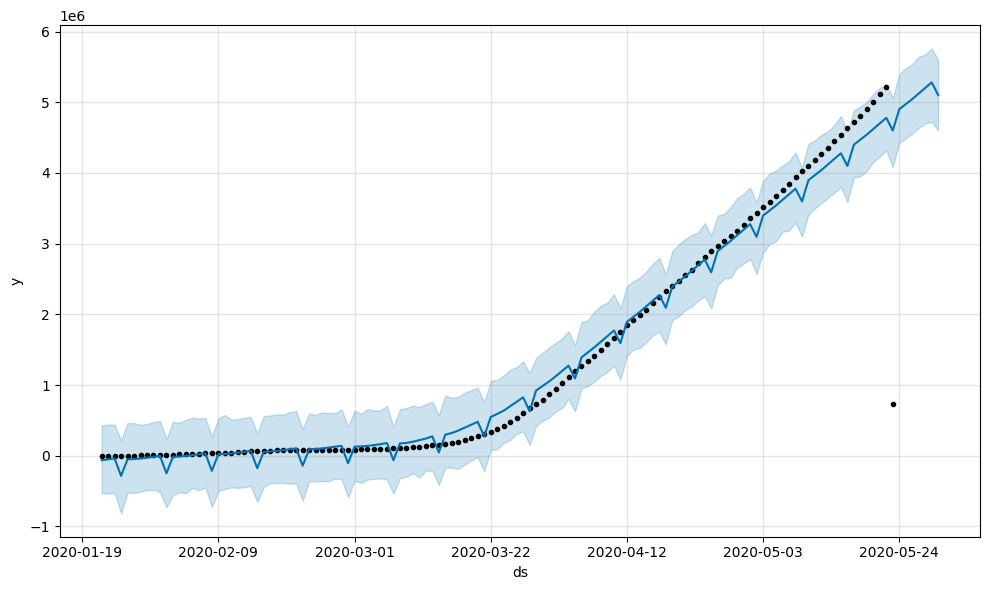

In [ ]:
# Visualizing
m.plot(forecast)
plt.show()

In [ ]:
import plotpy
import

In [ ]:
world = df1.groupby(by='Country/Region')[['Confirmed','Active','Deaths','Recovered']].sum().reset_index()
world

,Country/Region,Confirmed,Active,Deaths,Recovered
0,Afghanistan,151650,130093.0,4012,17545
1,Albania,38222,13389.0,1532,23301
2,Algeria,214564,100262.0,21406,92896
3,Andorra,39285,18460.0,2066,18759
4,Angola,1683,1112.0,119,452
...,...,...,...,...,...
182,West Bank and Gaza,18273,10801.0,101,7371
183,Western Sahara,274,112.0,0,162
184,Yemen,1780,1443.0,286,51
185,Zambia,11605,7481.0,187,3937


In [ ]:
import plotly
import plotly.express as px

In [ ]:
figure = px.choropleth(world,locations='Country/Region',
                        locationmode = 'country names',
                        color='Active',
                        hover_name='Country/Region', range_color=[1,20000],
                        color_continuous_scale='reds',
                        title='Countries with Active Cases')
figure.show()